In [3]:
# !pip install scikit-learn-extra
# !pip install "numpy<2.0"
import os 
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

In [4]:
import numpy as np
from statsmodels.tsa.arima_process import ArmaProcess

def durbin_levinson(pacf):
    p = len(pacf)
    phi = np.zeros(p)
    phis = np.zeros((p,p))
    phi[0] = pacf[0]
    phis[0,0] = pacf[0]
    for k in range(1, p):
        sum_val = pacf[k]
        for j in range(k):
            sum_val -= phis[k-1, j] * pacf[k-j-1]
        phi[k] = sum_val
        for j in range(k):
            phis[k,j] = phis[k-1,j] - pacf[k] * phis[k-1,k-j-1]
        phis[k,k] = pacf[k]
    return phis[-1]

    # Let's check this function, for a time series with partial
    # autocorrelations 0.4 and -0.3, the corresponding AR(2) coefficients
    # are 0.52 and -0.3. The function is correct!

print(durbin_levinson(np.array([0.4, -0.3])))

def simulate_ar3_clustering_dataset_with_similarity(n, K, series_length, random_state=None):
    rng = np.random.default_rng(random_state)
    alpha1 = rng.dirichlet(np.ones(K))
    cluster_assignments = rng.choice(K, size=n, p=alpha1)
    cluster_ar_coefs = []
    cluster_noise_vars = []
    for _ in range(K):
        pacf = rng.uniform(-1, 1, size=3)
        ar_coefs = durbin_levinson(pacf)
        ar_coefs_full = np.concatenate(([1], -ar_coefs))
        cluster_ar_coefs.append(ar_coefs_full)
        noise_var = rng.uniform(0.1, 2)
        cluster_noise_vars.append(noise_var)
    features = []
    for i in range(n):
        k = cluster_assignments[i]
        arma_process = ArmaProcess(cluster_ar_coefs[k], [1])
        ts = arma_process.generate_sample(nsample=series_length, scale=np.sqrt(cluster_noise_vars[k]), burnin=100)
        acfs = [1.0]
        for lag in range(1, 4):
            if lag < len(ts):
                acf = np.corrcoef(ts[:-lag], ts[lag:])[0,1]
            else:
                acf = 0.0
            acfs.append(acf)
        features.append(acfs[1:])
    D = np.array(features)             # shape (n, 3)
    C = cluster_assignments            # shape (n,)
    S = (C[:, None] == C[None, :]).astype(int)     # shape (n, n) similarity matrix
    return D, C, S

# Example usage
D, C, S = simulate_ar3_clustering_dataset_with_similarity(n=50, K=3, series_length=100, random_state=None)
print("Features shape:", D.shape)      # (50, 3)
print("Cluster assignments shape:", C.shape) # (50,)
print("Similarity matrix shape:", S.shape)   # (50, 50)
print(C)
print(S)
D.shape[0]

[ 0.52 -0.3 ]
Features shape: (50, 3)
Cluster assignments shape: (50,)
Similarity matrix shape: (50, 50)
[0 1 2 2 2 2 1 1 0 1 2 1 0 2 2 2 1 0 2 2 1 0 2 2 1 2 0 2 2 2 2 2 2 2 1 2 2
 2 2 2 2 0 2 2 2 2 0 2 2 2]
[[1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 1 ... 1 1 1]
 ...
 [0 0 1 ... 1 1 1]
 [0 0 1 ... 1 1 1]
 [0 0 1 ... 1 1 1]]


50

In [6]:
import torch

def prepare_pairwise_data(D, S):
    ''' Returns pairs (concat) and targets for all i < j '''
    n = D.shape[0]
    pairs = []
    targets = []
    for i in range(n):
        for j in range(i+1, n):
            pair = np.concatenate([D[i], D[j]])  # shape (6,)
            target = S[i, j]                     # 1 if same cluster, 0 if not
            pairs.append(pair)
            targets.append(target)
    return np.array(pairs), np.array(targets)

# Example preparation:
pairs, targets = prepare_pairwise_data(D, S)
print("Pairs shape:", pairs.shape)       # (n*(n-1)/2, 6)
print("Targets shape:", targets.shape)   # (n*(n-1)/2,)
print(pairs)
print(targets)

Pairs shape: (1225, 6)
Targets shape: (1225,)
[[-0.35689563 -0.49507723  0.32812979 -0.69414651  0.32743644  0.01979748]
 [-0.35689563 -0.49507723  0.32812979  0.84116721  0.84329082  0.89822688]
 [-0.35689563 -0.49507723  0.32812979  0.73580364  0.7068504   0.81082096]
 ...
 [ 0.52042757  0.402721    0.61784047  0.59581946  0.55383528  0.72414059]
 [ 0.52042757  0.402721    0.61784047  0.76055702  0.72108482  0.8860482 ]
 [ 0.59581946  0.55383528  0.72414059  0.76055702  0.72108482  0.8860482 ]]
[0 0 0 ... 1 1 1]


In [114]:
# Constructing the network

import torch
import torch.nn as nn

class PairwiseNN(nn.Module):
    def __init__(self, vector_dim=3, embed_dim=128, hidden_dim=256):
        super().__init__()
        # Embedding network phi applied independently to each vector
        self.phi = nn.Sequential(
            nn.Linear(vector_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU()
        )
        # Prediction network rho that takes aggregated embedding
        self.rho = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x shape: (batch_size, 6) where each pair concat of two 3-d vectors
        v1 = x[:, :3]  # first vector
        v2 = x[:, 3:]  # second vector

        emb1 = self.phi(v1)  # embed first vector
        emb2 = self.phi(v2)  # embed second vector

        combined = emb1 + emb2  # symmetric aggregation (sum)

        out = self.rho(combined)  # predict
        return out.squeeze(-1)  # shape: (batch_size,)

# Example initialization:
model = PairwiseNN(vector_dim=3, embed_dim=128, hidden_dim=256)



In [115]:
# Training

import torch
import torch.nn as nn
import numpy as np

n_series = 50
K = 3
series_lengths = [25, 50, 100, 150, 200, 300, 400, 500]


num_epochs = 1
units_per_epoch = 200000  # total simulated datasets per epoch
datasets_per_batch = 64  # simulate & batch together N datasets per update
early_stopping_patience = 100


models_by_length = {}


for T in series_lengths:
    print(f"\nTraining model for series length: {T}")

    # Use vector_dim=3 as each component vector has dimension 3
    model = PairwiseNN(vector_dim=3, embed_dim=128, hidden_dim=256)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCELoss()

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        losses = []
        indices = np.arange(units_per_epoch // datasets_per_batch)
        for _ in indices:
            batch_pairs = []
            batch_targets = []
            for _ in range(datasets_per_batch):
                D, C, S = simulate_ar3_clustering_dataset_with_similarity(n=n_series, K=K, series_length=T)
                pairs, targets = prepare_pairwise_data(D, S)
                batch_pairs.append(pairs)
                batch_targets.append(targets)
            pairs_tensor = torch.tensor(np.vstack(batch_pairs)).float()
            targets_tensor = torch.tensor(np.hstack(batch_targets)).float()

            model.train()
            optimizer.zero_grad()
            outputs = model(pairs_tensor)
            loss = criterion(outputs, targets_tensor)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        mean_loss = np.mean(losses)

        # Validation step
        model.eval()
        Dv, Cv, Sv = simulate_ar3_clustering_dataset_with_similarity(n=n_series, K=K, series_length=T)
        pairs_val, targets_val = prepare_pairwise_data(Dv, Sv)
        pairs_tensor_val = torch.tensor(pairs_val).float()
        targets_tensor_val = torch.tensor(targets_val).float()
        with torch.no_grad():
            outputs_val = model(pairs_tensor_val)
            val_loss = criterion(outputs_val, targets_tensor_val).item()

        print(f"Epoch {epoch+1}, train loss: {mean_loss:.4f}, val loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Optionally save the best model state here
            # best_model_state = model.state_dict()
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch+1} (best val loss {best_val_loss:.4f})")
            break

    # Save the trained model in memory
    models_by_length[f"model_{T}"] = model

print("\nTraining completed. Models saved in memory.")



Training model for series length: 25
Epoch 1, train loss: 0.3231, val loss: 0.0593

Training model for series length: 50
Epoch 1, train loss: 0.2422, val loss: 0.0504

Training model for series length: 100
Epoch 1, train loss: 0.1950, val loss: 0.0501

Training model for series length: 150
Epoch 1, train loss: 0.1829, val loss: 0.1812

Training model for series length: 200
Epoch 1, train loss: 0.1798, val loss: 0.0028

Training model for series length: 300
Epoch 1, train loss: 0.1677, val loss: 0.0363

Training model for series length: 400
Epoch 1, train loss: 0.1647, val loss: 0.0213

Training model for series length: 500
Epoch 1, train loss: 0.1607, val loss: 0.0214

Training completed. Models saved in memory.


In [116]:
# Sanity check for permutation invariance

import torch

# Create example input pairs with two 3-d vectors swapped
pair1 = torch.tensor([[1.0, 2.0, 3.0, 4.0, 5.0, 6.0]])  # (v1, v2)
pair2 = torch.tensor([[4.0, 5.0, 6.0, 1.0, 2.0, 3.0]])  # (v2, v1)

# Forward pass through the model
output1 = model(pair1)
output2 = model(pair2)

print(f"Output for pair1 (v1, v2): {output1.item():.6f}")
print(f"Output for pair2 (v2, v1): {output2.item():.6f}")
print(f"Outputs are equal: {torch.isclose(output1, output2).item()}")


Output for pair1 (v1, v2): 0.000000
Output for pair2 (v2, v1): 0.000000
Outputs are equal: True


In [124]:
# Evaluation

# !pip install scikit-learn-extra
# !pip install "numpy<2.0"
from sklearn.cluster import SpectralClustering, KMeans, AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
from sklearn_extra.cluster import KMedoids
import numpy as np
import torch
import networkx as nx
import community.community_louvain as community_louvain
import pandas as pd

# Assume models_by_length dictionary contains trained models keyed by "model_<T>"
# Example: models_by_length = {"model_25": model_25, ..., "model_500": model_500}

num_trials = 10000
n_series = 50
K = 3
series_lengths = [25, 50, 100, 150, 200, 300, 400, 500]

# Dictionary to store ARIs for each method per series length
results = {T: {
    "spectral": [],
    "kmeans": [],
    "kmedoids": [],
    "agglo": [],
    "louvain_pred": []
} for T in series_lengths}

for T in series_lengths:
    model = models_by_length[f"model_{T}"]
    print(f"\nEvaluating model trained on series length {T}")

    for trial in range(num_trials):
        D_test, C_test, S_test = simulate_ar3_clustering_dataset_with_similarity(n=n_series, K=K, series_length=T)
        pairs, targets = prepare_pairwise_data(D_test, S_test)
        pairs_tensor = torch.tensor(pairs).float()

        with torch.no_grad():
            pred_sim_probs = model(pairs_tensor).detach().cpu().numpy()

            pred_sim_matrix = np.zeros((n_series, n_series), dtype=float)
            idx = 0
            for i in range(n_series):
                for j in range(i + 1, n_series):
                    pred_sim_matrix[i, j] = pred_sim_probs[idx]
                    pred_sim_matrix[j, i] = pred_sim_probs[idx]
                    idx += 1
            np.fill_diagonal(pred_sim_matrix, 1.0)

            spectral = SpectralClustering(n_clusters=K, affinity="precomputed", random_state=trial)
            spectral_labels = spectral.fit_predict(pred_sim_matrix)
            spectral_ari = adjusted_rand_score(C_test, spectral_labels)
            results[T]["spectral"].append(spectral_ari)

            kmeans = KMeans(n_clusters=K, n_init=200, random_state=trial)
            kmeans_labels = kmeans.fit_predict(D_test)
            kmeans_ari = adjusted_rand_score(C_test, kmeans_labels)
            results[T]["kmeans"].append(kmeans_ari)

            kmedoids = KMedoids(n_clusters=K, random_state=trial, init="k-medoids++")
            kmedoids_labels = kmedoids.fit_predict(D_test)
            kmedoids_ari = adjusted_rand_score(C_test, kmedoids_labels)
            results[T]["kmedoids"].append(kmedoids_ari)

            agglo = AgglomerativeClustering(n_clusters=K, linkage="ward")
            agglo_labels = agglo.fit_predict(D_test)
            agglo_ari = adjusted_rand_score(C_test, agglo_labels)
            results[T]["agglo"].append(agglo_ari)

            G_pred = nx.from_numpy_array(pred_sim_matrix)
            partition_pred = community_louvain.best_partition(G_pred, random_state=trial)
            louvain_pred_labels = np.array([partition_pred[i] for i in range(n_series)])
            louvain_pred_ari = adjusted_rand_score(C_test, louvain_pred_labels)
            results[T]["louvain_pred"].append(louvain_pred_ari)

        if (trial + 1) % 100 == 0:
            print(f"Trial {trial + 1}/{num_trials} completed for series length {T}")

# Prepare summary table data
summary_data = {
    "Series Length": [],
    "Spectral Clustering": [],
    "Louvain on Affinities": [],
    "KMeans on Features": [],
    "KMedoids on Features": [],
    "Agglomerative (Ward)": [],
}

for T in series_lengths:
    summary_data["Series Length"].append(T)
    summary_data["Spectral Clustering"].append(np.mean(results[T]["spectral"]))
    summary_data["Louvain on Affinities"].append(np.mean(results[T]["louvain_pred"]))
    summary_data["KMeans on Features"].append(np.mean(results[T]["kmeans"]))
    summary_data["KMedoids on Features"].append(np.mean(results[T]["kmedoids"]))
    summary_data["Agglomerative (Ward)"].append(np.mean(results[T]["agglo"]))

df_summary = pd.DataFrame(summary_data)
import os

output_dir = "df_summary_scenario_1_50_3"
os.makedirs(output_dir, exist_ok=True)
df_summary.to_csv('df_summary_scenario_1_50_3/df_summary_scenario_1_50_3.csv', index=False)
print(df_summary.to_string(index=False, float_format='%.3f'))


Evaluating model trained on series length 25
Trial 100/10000 completed for series length 25
Trial 200/10000 completed for series length 25
Trial 300/10000 completed for series length 25
Trial 400/10000 completed for series length 25
Trial 500/10000 completed for series length 25
Trial 600/10000 completed for series length 25
Trial 700/10000 completed for series length 25
Trial 800/10000 completed for series length 25
Trial 900/10000 completed for series length 25
Trial 1000/10000 completed for series length 25
Trial 1100/10000 completed for series length 25
Trial 1200/10000 completed for series length 25
Trial 1300/10000 completed for series length 25
Trial 1400/10000 completed for series length 25
Trial 1500/10000 completed for series length 25
Trial 1600/10000 completed for series length 25
Trial 1700/10000 completed for series length 25
Trial 1800/10000 completed for series length 25
Trial 1900/10000 completed for series length 25
Trial 2000/10000 completed for series length 25
Tri

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Trial 200/10000 completed for series length 300
Trial 300/10000 completed for series length 300
Trial 400/10000 completed for series length 300
Trial 500/10000 completed for series length 300
Trial 600/10000 completed for series length 300
Trial 700/10000 completed for series length 300
Trial 800/10000 completed for series length 300
Trial 900/10000 completed for series length 300
Trial 1000/10000 completed for series length 300
Trial 1100/10000 completed for series length 300
Trial 1200/10000 completed for series length 300
Trial 1300/10000 completed for series length 300
Trial 1400/10000 completed for series length 300
Trial 1500/10000 completed for series length 300
Trial 1600/10000 completed for series length 300
Trial 1700/10000 completed for series length 300
Trial 1800/10000 completed for series length 300
Trial 1900/10000 completed for series length 300
Trial 2000/10000 completed for series length 300
Trial 2100/10000 completed for series length 300
Trial 2200/10000 completed f

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Trial 2600/10000 completed for series length 300
Trial 2700/10000 completed for series length 300
Trial 2800/10000 completed for series length 300
Trial 2900/10000 completed for series length 300
Trial 3000/10000 completed for series length 300
Trial 3100/10000 completed for series length 300
Trial 3200/10000 completed for series length 300
Trial 3300/10000 completed for series length 300


...

Trial 2800/10000 completed for series length 500
Trial 2900/10000 completed for series length 500
Trial 3000/10000 completed for series length 500
Trial 3100/10000 completed for series length 500
Trial 3200/10000 completed for series length 500
Trial 3300/10000 completed for series length 500
Trial 3400/10000 completed for series length 500
Trial 3500/10000 completed for series length 500
Trial 3600/10000 completed for series length 500
Trial 3700/10000 completed for series length 500
Trial 3800/10000 completed for series length 500
Trial 3900/10000 completed for series length 500
Trial 4000/10000 completed for series length 500
Trial 4100/10000 completed for series length 500
Trial 4200/10000 completed for series length 500
Trial 4300/10000 completed for series length 500
Trial 4400/10000 completed for series length 500
Trial 4500/10000 completed for series length 500
Trial 4600/10000 completed for series length 500
Trial 4700/10000 completed for series length 500
Trial 4800/10000 com

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Trial 8100/10000 completed for series length 500
Trial 8200/10000 completed for series length 500
Trial 8300/10000 completed for series length 500
Trial 8400/10000 completed for series length 500
Trial 8500/10000 completed for series length 500


/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Trial 8600/10000 completed for series length 500
Trial 8700/10000 completed for series length 500
Trial 8800/10000 completed for series length 500
Trial 8900/10000 completed for series length 500
Trial 9000/10000 completed for series length 500
Trial 9100/10000 completed for series length 500
Trial 9200/10000 completed for series length 500
Trial 9300/10000 completed for series length 500
Trial 9400/10000 completed for series length 500
Trial 9500/10000 completed for series length 500
Trial 9600/10000 completed for series length 500
Trial 9700/10000 completed for series length 500
Trial 9800/10000 completed for series length 500
Trial 9900/10000 completed for series length 500
Trial 10000/10000 completed for series length 500
 Series Length  Spectral Clustering  Louvain on Affinities  KMeans on Features  KMedoids on Features  Agglomerative (Ward)
            25                0.744                  0.662               0.544                 0.530                 0.552
            50    

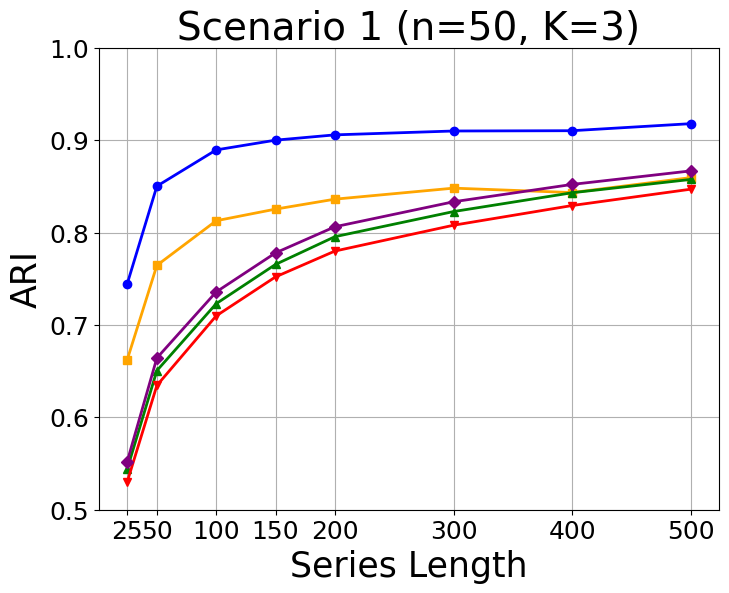

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

csv_path = 'df_summary_scenario_1_50_3/df_summary_scenario_1_50_3.csv'
df_summary = pd.read_csv(csv_path)

plt.figure(figsize=(8, 6))

plt.plot(df_summary["Series Length"], df_summary["Spectral Clustering"], marker='o', color='blue', linewidth=2)
plt.plot(df_summary["Series Length"], df_summary["Louvain on Affinities"], marker='s', color='orange', linewidth=2)
plt.plot(df_summary["Series Length"], df_summary["KMeans on Features"], marker='^', color='green', linewidth=2)
plt.plot(df_summary["Series Length"], df_summary["KMedoids on Features"], marker='v', color='red', linewidth=2)
plt.plot(df_summary["Series Length"], df_summary["Agglomerative (Ward)"], marker='D', color='purple', linewidth=2)

plt.xlabel('Series Length', fontsize=25)
plt.ylabel('ARI', fontsize=25)
plt.title('Scenario 1 (n=50, K=3)', fontsize=28)
plt.grid(True)
plt.xticks(df_summary["Series Length"], fontsize=18)
plt.yticks(fontsize=18)
plt.ylim(0.5, 1.0)

plt.savefig('fig1.png', dpi=300, bbox_inches='tight')
plt.show()